# Overview

## Create the simulation

In [ ]:
from functools import partial
from lucifex.io import write
from lucifex.sim import run, xdmf_to_npz
from lucifex.plt import (
    plot_colormap, plot_contours, create_multifigure, plot_colormap_multifigure,
    get_ipynb_file_name, set_ipynb_variable, plot_line, save_figure,
)
from lucifex.solver import OptionsPETSc
from lucifex.utils.npy_utils import as_index, derivative
from crocodil.theory.system_b import mass_capillary_initial, mass_dissolved_initial
from crocodil.dns.system_b import dns_system_b, SYSTEM_B_REFERENCE, plot_arc_lines

STORE = 1
WRITE = None
DIR_ROOT = f'./figures/{get_ipynb_file_name()}'
NR = set_ipynb_variable('NR', 32)
ANIM = set_ipynb_variable('ANIM', False)

STREAMF = False

simulation = dns_system_b(
    store_delta=STORE, 
    write_delta=WRITE, 
    dir_root=DIR_ROOT, 
    dir_uid=True,
)(
    Nr=NR,
    scaling='advective',
    **SYSTEM_B_REFERENCE.replace(Ra=800.0, Pe=400.0),
    dt_max=0.1,
    dt_Cu=0.75,
    dt_Cd=0.75,
    dt_Cr=0.1,
    c_stabilization=None,
    c_limits=True,
    diagnostic=True,
    flow_petsc=(
        (
            OptionsPETSc('cg', 'hypre'), None) if STREAMF else
            OptionsPETSc(
            ksp_type='preonly', 
            pc_type='lu', 
            pc_factor_mat_solver_type='mumps',
            blocked=False,
        )
    ),
)

Rinner, Router = simulation['Rinner', 'Router']
Ra, Da, epsilon, zeta0, sr, cr = (
    float(i) for i in simulation['Ra', 'Da', 'epsilon', 'zeta0', 'sr', 'cr']
)

# sr_crit = critical_saturation(zeta0, cr, epsilon)
# print(f'sr = {sr} , sr_crit = {sr_crit}')

save_fig = partial(save_figure, dir_path=simulation.dir_path, prefix=False)

## Run the simulation

In [ ]:
n_stop = set_ipynb_variable('N_STOP', 400)
t_stop = 100.0
dt_init = 1e-6
n_init = 10

run(simulation, n_stop=n_stop, t_stop=t_stop, dt_init=dt_init, n_init=n_init, show_progress=True)
if WRITE: 
    xdmf_to_npz(simulation, delete_xdmf=False)
else:
    write(simulation.parameters, simulation.parameter_file, simulation.dir_path, mode='w')

s, c, u = simulation['s', 'c', 'u']
if STREAMF:
    psi = simulation['psi']
else:
    up = simulation['up']
mC, mD = simulation['mC', 'mD']

  0%|          | 0/400 [00:00<?, ?it/s]

## Visualization

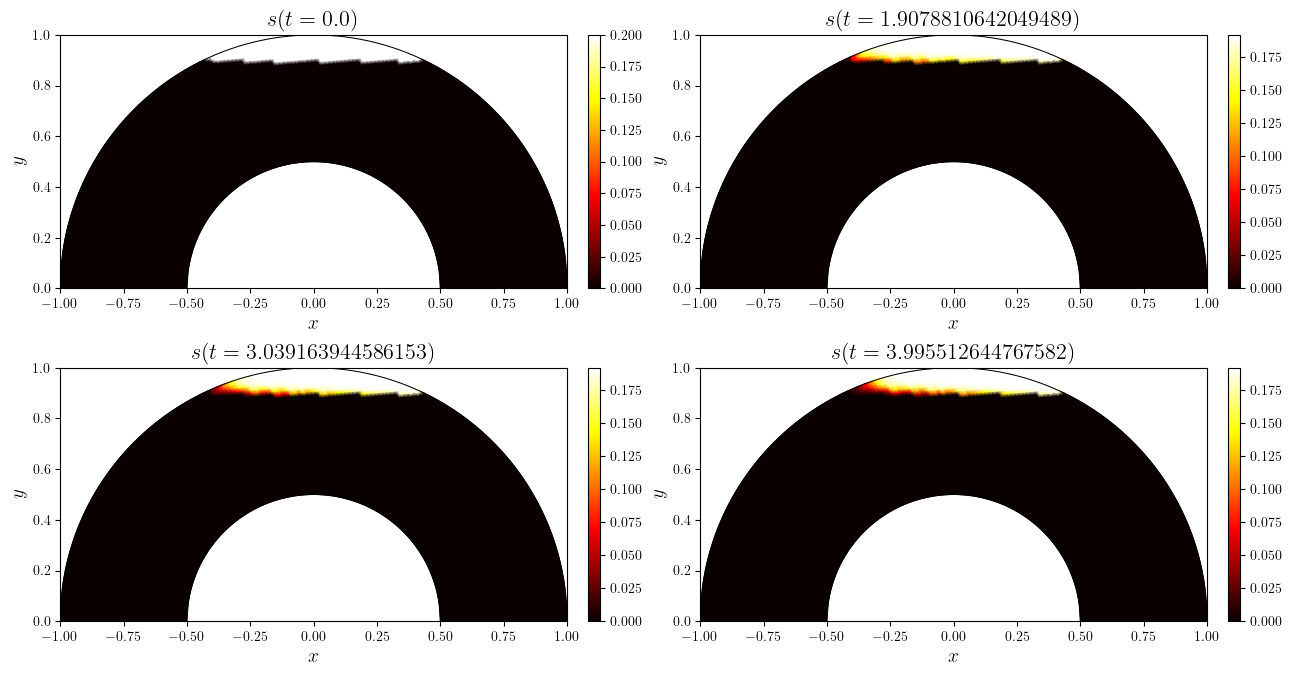

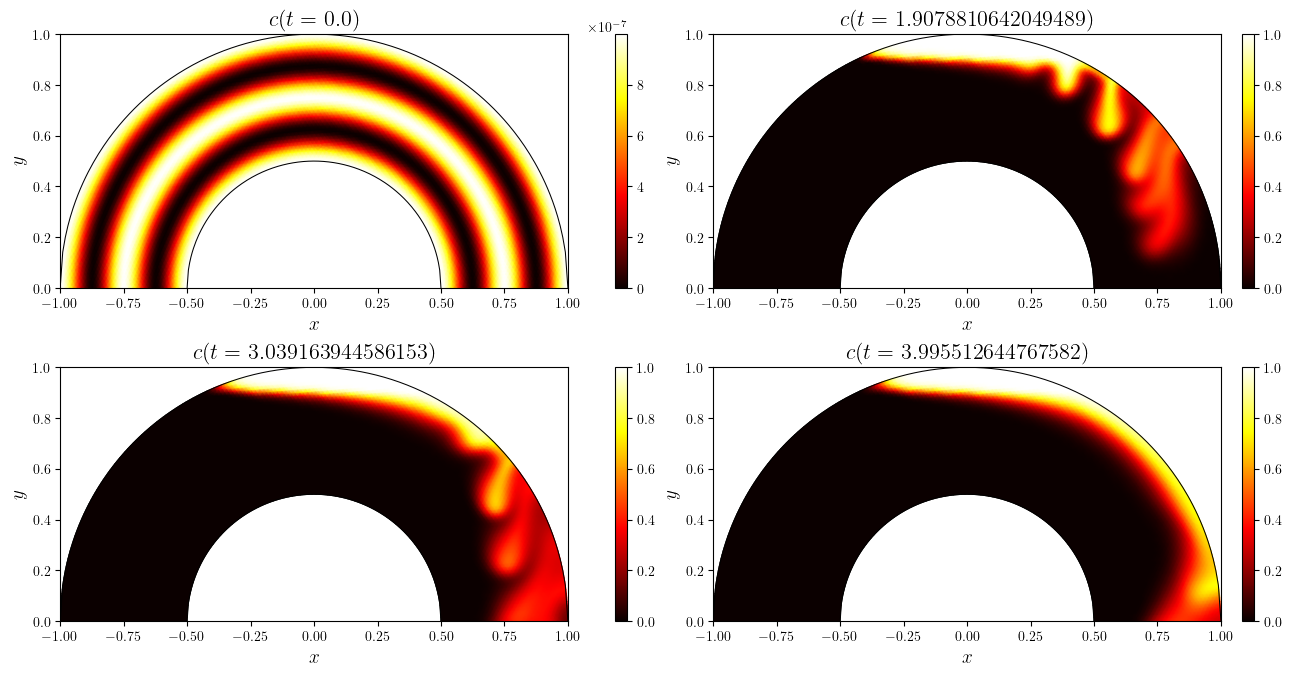

In [ ]:
contours = STREAMF
time_indices = as_index(c.time_series, (0, 0.5, 0.75, -1), fraction=True)

w_opts = [s, c]
if STREAMF: w_opts.append(psi) 
w_texs = ['s', 'c']
if STREAMF: w_texs.append('\psi')

for w, tex in zip(w_opts, w_texs):
    mfig, axs, _ = plot_colormap_multifigure(n_cols=2, cbars=True)(
        [w.series[i] for i in time_indices],
        title=[f'${tex}(t={w.time_series[i]})$' for i in time_indices],
    )
    for ax in axs:
        plot_arc_lines(ax, Rinner, Router)
        if contours:
            for i in time_indices:
                plot_contours(mfig, ax, psi.series[i], cmap='viridis')

## Diagnostics

### Mass

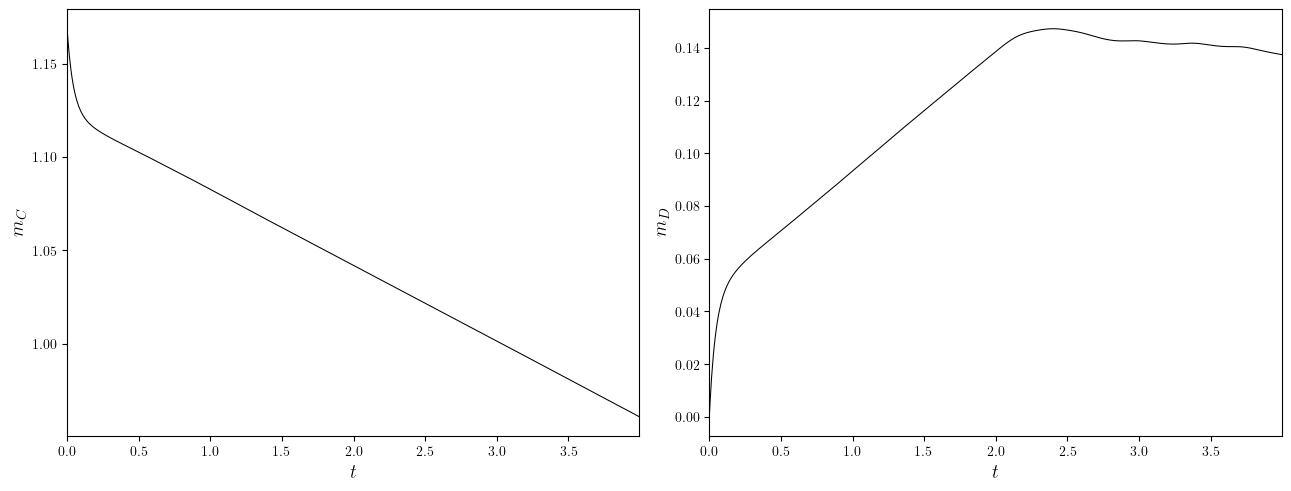

In [ ]:
mfig, axs, _ = create_multifigure(n_cols=2)

plot_line(
    mfig, axs[0],
    (mC.time_series, mC.value_series),
    x_label='$t$',
    y_label='$m_C$',
)
plot_line(
    mfig, axs[1],
    (mD.time_series, mD.value_series),
    x_label='$t$',
    y_label='$m_D$'
)

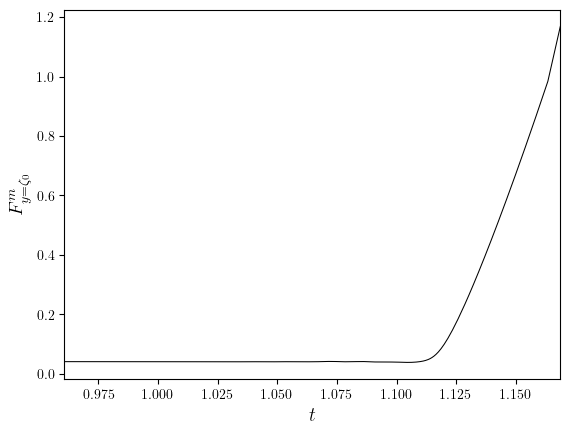

In [ ]:
l_contour = 1.0 # FIXME get proper chord length
fMass = -(1 / l_contour) * derivative(mC.value_series, mC.time_series)

fig, ax = plot_line(
    (mC.value_series, fMass),
    x_label='$t$',
    y_label='$F^m_{y=\zeta_0}$'
)

### Velocity norms

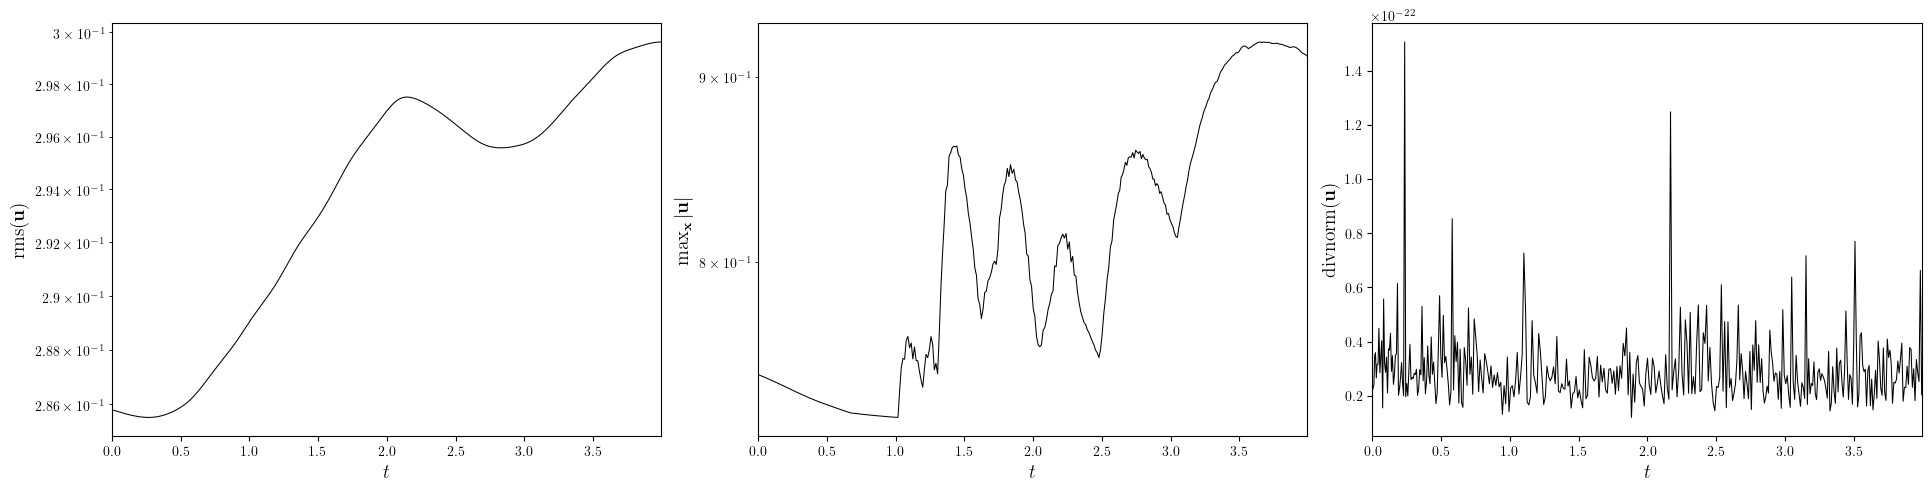

In [ ]:
uRMS, uMinMax, uDiv = simulation['uRMS', 'uMinMax', 'uDiv']
uMax = uMinMax.sub(1)

mfig, axs, _ = create_multifigure(n_cols=3)

plot_line(
    mfig, axs[0],
    (uRMS.time_series, uRMS.value_series),
    x_label='$t$',
    y_label='$\mathrm{rms}(\mathbf{u})$',
)
axs[0].set_yscale('log')

plot_line(
    mfig, axs[1],
    (uMax.time_series, uMax.value_series),
    x_label='$t$',
    y_label='$\max_{\mathbf{x}}|\mathbf{u}|$',
)
axs[1].set_yscale('log')

plot_line(
    mfig, axs[2],
    (uDiv.time_series, uDiv.value_series),
    x_label='$t$',
    y_label='$\mathrm{divn}(\mathbf{u})$',
)

# save_fig('uRMS(t)_uMax(t)_uDiv(t)')(mfig)

### Thumbnail image

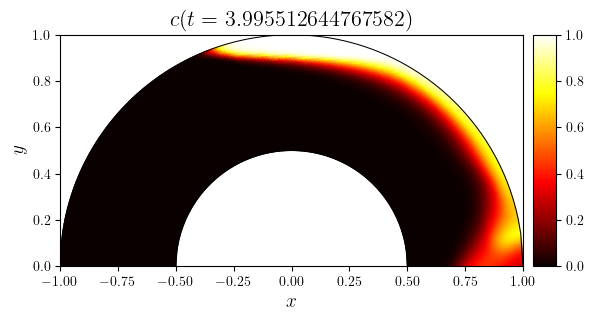

In [ ]:
time_index = -1
fig, ax = plot_colormap(
    c.series[time_index], 
    title=f'$c(t={c.time_series[time_index]})$',
)
plot_arc_lines(ax, Rinner, Router)
save_figure('thumbnail', DIR_ROOT, prefix=False)(fig, file_ext='png')